# Age via Coherence (functional connectivity) + regression


# PART 4 EXPLORING AGE - COHERENCE

### EEG Coherence Analysis (REC, Eyes Closed)

#### What is coherence?

While PSD measures **how much** activity each brain region produces, **coherence** measures how **synchronised** two regions are — whether they oscillate together (coherence ≈ 1) or independently (coherence ≈ 0).

This is a fundamentally different type of information: **functional connectivity** rather than spectral power.

#### Method

We compute magnitude-squared coherence using Welch's method (`scipy.signal.coherence`):
- **Window size**: 128 samples = 1 second at 128 Hz
- **Overlap**: 50% → ~19 windows over the 10-second REC segment
- **Averaging over multiple windows is essential**: single-window coherence is always 1 (mathematical property), so we need enough windows for reliable estimates
- **Bias**: coherence estimates are upward-biased by ≈ 1/n_windows ≈ 0.05; since all subjects have the same segment length, this bias is constant and does not affect comparisons

The result is one **14×14 symmetric matrix per frequency band**, where entry (i, j) represents the coherence between channels i and j.

### Mathematical definition of coherence

The **magnitude-squared coherence** between two signals $x$ and $y$ at frequency $f$ is defined as:

$$C_{xy}(f) = \frac{|S_{xy}(f)|^2}{S_{xx}(f) \cdot S_{yy}(f)}$$

Where:
- $S_{xy}(f)$ = cross-spectral density between channels $x$ and $y$ (averaged over windows)
- $S_{xx}(f)$, $S_{yy}(f)$ = auto-spectral densities of each channel (averaged over windows)
- $C_{xy}(f) \in [0, 1]$: 0 = independent, 1 = perfectly synchronised

The averaging over multiple windows is essential — without it, $C_{xy}(f) = 1$ for any pair of signals (mathematical property of single-window estimation). We use Welch's method with 1-second windows (128 samples) and 50% overlap, yielding ~19 windows per 10-second REC segment.

For each frequency band (delta, theta, alpha, beta, gamma), we compute **band-averaged coherence**:

$$\bar{C}_{xy}^{band} = \frac{1}{|F_{band}|} \sum_{f \in F_{band}} C_{xy}(f)$$

### References

- **Coherence in EEG — foundational method:**
  Nunez, P. L., & Srinivasan, R. (2006). *Electric Fields of the Brain: The Neurophysics of EEG* (2nd ed.). Oxford University Press.

- **Age-related changes in EEG coherence:**
  Barry, R. J., & De Blasio, F. M. (2017). EEG differences between eyes-closed and eyes-open resting remain in healthy ageing. *Biological Psychology*, 129, 293–304.

- **Gamma coherence decline with ageing:**
  Böttger, D., Herrmann, C. S., & von Cramon, D. Y. (2002). Amplitude differences of evoked alpha and gamma oscillations in two different age groups. *International Journal of Psychophysiology*, 45(3), 245–251.

- **HAROLD model (hemispheric compensation in ageing):**
  Cabeza, R. (2002). Hemispheric asymmetry reduction in older adults: The HAROLD model. *Psychology and Aging*, 17(1), 85–100.

- **Frontal alpha asymmetry and handedness:**
  Ocklenburg, S., Güntürkün, O., & Beste, C. (2012). Lateralized neural mechanisms underlying the modulation of response inhibition processes. *NeuroImage*, 55(4), 1771–1778.

- **Left-hander heterogeneity in hemispheric organisation:**
  Hervé, P. Y., Zago, L., Petit, L., Mazoyer, B., & Tzourio-Mazoyer, N. (2013). Revisiting human hemispheric specialization with neuroimaging. *Trends in Cognitive Sciences*, 17(2), 69–80.

- **ECAPA-TDNN speaker embeddings:**
  Desplanques, B., Thienpondt, J., & Demuynck, K. (2020). ECAPA-TDNN: Emphasized Channel Attention, Propagation and Aggregation in TDNN Based Speaker Verification. *Proc. Interspeech 2020*, 3830–3834.

- **EEGNet architecture:**
  Lawhern, V. J., Solon, A. J., Waytowich, N. R., Gordon, S. M., Hung, C. P., & Lance, B. J. (2018). EEGNet: A compact convolutional neural network for EEG-based brain–computer interfaces. *Journal of Neural Engineering*, 15(5), 056013.

- **BIOMEX database:**
  Moreno-Rodríguez, J. C., et al. (2021). BIOMEX-DB: A Cognitive Audiovisual Dataset for Unimodal and Multimodal Biometric Systems. *IEEE Access*, 9, 33932–33944.

=== Coherence matrices for F001 (REC) ===
  Bands computed : ['delta', 'theta', 'alpha', 'beta', 'gamma']
  Matrix shape   : (14, 14)  (14 channels)

  Band     mean coh     min     max
  --------------------------------
  delta       0.132   0.020   0.622
  theta       0.118   0.008   0.370
  alpha       0.236   0.048   0.540
  beta        0.092   0.029   0.297
  gamma       0.076   0.037   0.175


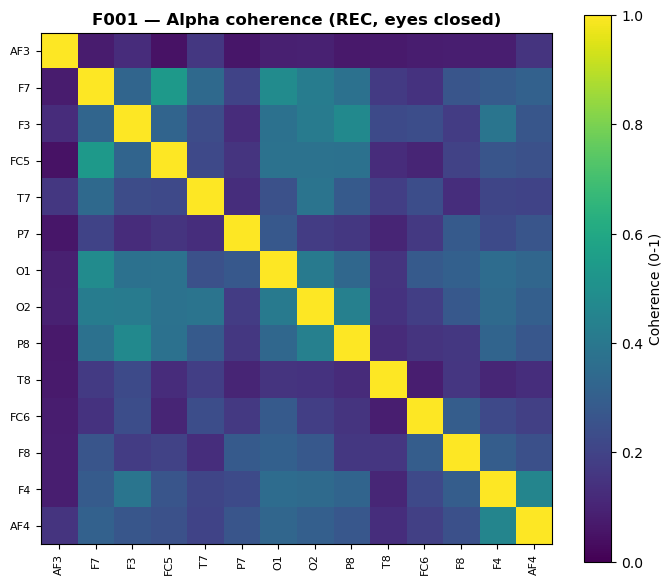

In [8]:
# ============================================================
# CELL COH-1: Band-averaged coherence between channel pairs
#
# Coherence = magnitude-squared spectral coherence (0 to 1).
# Computed with scipy.signal.coherence, which uses Welch's
# method internally (it averages over windows — essential,
# see note on bias below).
#
# We use nperseg=128 (1 s windows at 128 Hz):
#   → ~19 windows over the 10 s REC segment (50% overlap)
#   → more windows = less coherence bias (bias ≈ 1/n_windows)
#   → frequency resolution = 1 Hz, fine enough for bands
#
# Output per subject: one 14x14 symmetric matrix PER BAND.
# Diagonal = 1 (a channel is perfectly coherent with itself).
# ============================================================

from scipy.signal import coherence

# Redefined here so this section is self-contained
BANDS = {
    'delta': (1,  4),
    'theta': (4,  8),
    'alpha': (8, 13),
    'beta' : (13, 30),
    'gamma': (30, 50),
}


def compute_coherence_matrix(segment, sfreq=SFREQ, bands=BANDS, nperseg=128):
    """
    Band-averaged coherence between every pair of EEG channels.

    Parameters
    ----------
    segment : np.ndarray, shape (14, n_samples) — one clean EEG segment
    sfreq   : float — sampling frequency (128 Hz)
    bands   : dict — {band_name: (f_low, f_high)}
    nperseg : int  — window length in samples for Welch averaging

    Returns
    -------
    coh : dict {band_name: np.ndarray (14, 14)}
          Symmetric coherence matrices, diagonal forced to 1.
    """
    n_ch        = segment.shape[0]
    nperseg_eff = min(nperseg, segment.shape[1])

    # Initialise one matrix per band (diagonal = 1)
    coh = {band: np.eye(n_ch) for band in bands}

    # Loop over the upper triangle of channel pairs only (matrix is symmetric)
    for i in range(n_ch):
        for j in range(i + 1, n_ch):
            f, Cxy = coherence(segment[i], segment[j],
                               fs=sfreq, nperseg=nperseg_eff)
            for band, (flo, fhi) in bands.items():
                mask = (f >= flo) & (f < fhi)
                val  = Cxy[mask].mean()
                coh[band][i, j] = val
                coh[band][j, i] = val   # mirror — symmetric matrix

    return coh


# ---- Test on F001 REC ----
segs_f001 = extract_condition_segments(find_edf('F001', session='G10'))
coh_f001  = compute_coherence_matrix(segs_f001['REC'])

print("=== Coherence matrices for F001 (REC) ===")
print(f"  Bands computed : {list(coh_f001.keys())}")
print(f"  Matrix shape   : {coh_f001['alpha'].shape}  (14 channels)\n")

# Quick numeric summary per band (mean over the 91 unique off-diagonal pairs)
iu = np.triu_indices(14, k=1)   # indices of the upper triangle, no diagonal
print(f"  {'Band':6s}  {'mean coh':>9s}  {'min':>6s}  {'max':>6s}")
print("  " + "-" * 32)
for band, M in coh_f001.items():
    pairs = M[iu]
    print(f"  {band:6s}  {pairs.mean():>9.3f}  {pairs.min():>6.3f}  {pairs.max():>6.3f}")

# ---- Visual: alpha coherence heatmap ----
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(coh_f001['alpha'], vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(range(14)); ax.set_xticklabels(EEG_CHANNELS, rotation=90, fontsize=8)
ax.set_yticks(range(14)); ax.set_yticklabels(EEG_CHANNELS, fontsize=8)
ax.set_title("F001 — Alpha coherence (REC, eyes closed)", fontweight='bold')
plt.colorbar(im, ax=ax, label="Coherence (0-1)")
plt.tight_layout()
plt.show()

**Alpha band shows the highest mean coherence (0.236)**, which is expected during eyes-closed rest — the brain produces strong, widespread alpha oscillations in this state (the same Berger effect confirmed in Part 2).

The heatmap confirms two key properties of real functional connectivity:
- **Spatial structure**: nearby electrode pairs (e.g. O1–O2, F3–FC5) show higher coherence than distant pairs (e.g. AF3–T8) — coherence decays with physical distance
- **Frequency structure**: slow rhythms (delta, alpha) show higher coherence than fast rhythms (beta, gamma) — consistent with the known physics of volume conduction and long-range neural synchronisation

These patterns confirm the coherence pipeline is working correctly. Next step: compute coherence for all 49 subjects and test whether it changes with age.

### COH-2: Coherence by hemisphere — all subjects

#### Why split by hemisphere?

The brain's two hemispheres can be synchronised internally (intra-hemispheric coherence) or with each other (interhemispheric coherence). These are functionally different:

- **Intra-hemispheric** coherence reflects local network coordination within one hemisphere
- **Interhemispheric** coherence reflects communication across the corpus callosum — the main bridge between hemispheres

The literature reports that both change with age, but in different ways: intra-hemispheric coherence in high frequencies (gamma) tends to *decrease*, while interhemispheric coherence in lower frequencies sometimes *increases* as a compensatory mechanism (the HAROLD model — Hemispheric Asymmetry Reduction in OLDer adults, Cabeza 2002).

#### Hemisphere mapping (Emotiv Epoc channel order)

| Left (idx 0–6) | Right (idx 7–13) |
|-----------------|------------------|
| AF3, F7, F3, FC5, T7, P7, O1 | O2, P8, T8, FC6, F8, F4, AF4 |

#### Metrics per subject
- **Intra-left**: mean coherence across 21 left-hemisphere pairs
- **Intra-right**: mean coherence across 21 right-hemisphere pairs
- **Interhemispheric**: mean coherence across 49 cross-hemisphere pairs

Total: 3 metrics × 5 bands = **15 connectivity features per subject**.

In [9]:
# ============================================================
# CELL COH-2: Build coherence feature matrix for all subjects
#
# For each subject with a valid REC segment we compute three
# connectivity summary metrics per frequency band:
#
#   intra_left        — mean coherence within left hemisphere
#   intra_right       — mean coherence within right hemisphere
#   interhemispheric  — mean coherence across hemispheres
#
# Emotiv Epoc hemisphere split (follows EEG_CHANNELS order):
#   Left  (idx 0–6)  : AF3, F7, F3, FC5, T7, P7, O1
#   Right (idx 7–13) : O2, P8, T8, FC6, F8, F4, AF4
#
# Result: DataFrame (n_subjects × 15 features + metadata)
#   15 = 5 bands × 3 metrics
# ============================================================

import time

# ── Hemisphere index definitions ──────────────────────────────────
LEFT_IDX  = list(range(0, 7))
RIGHT_IDX = list(range(7, 14))

# Upper-triangle pairs within each hemisphere (no self-pairs)
iu_left  = [(i, j) for i in LEFT_IDX  for j in LEFT_IDX  if j > i]
iu_right = [(i, j) for i in RIGHT_IDX for j in RIGHT_IDX if j > i]

# All cross-hemisphere pairs
inter_pairs = [(i, j) for i in LEFT_IDX for j in RIGHT_IDX]

print("=== Hemisphere pair counts ===")
print(f"  Intra-left       : {len(iu_left):3d} pairs")
print(f"  Intra-right      : {len(iu_right):3d} pairs")
print(f"  Interhemispheric : {len(inter_pairs):3d} pairs")
print(f"\nProcessing {len(metadata)} subjects — ~2 min on CPU...\n")
print(f"  {'Subject':8s}  Status")
print("  " + "-" * 22)

records = []
t_start = time.time()

for _, row in metadata.iterrows():
    sid      = row['subject_id']
    edf_path = find_edf(sid, session='G10')

    if edf_path is None:
        print(f"  {sid:8s}  [no EDF]")
        continue

    try:
        segs = extract_condition_segments(edf_path)
        rec  = segs.get('REC')

        if rec is None:
            print(f"  {sid:8s}  [no REC marker]")
            continue

        coh    = compute_coherence_matrix(rec)
        record = {'subject_id': sid}

        for band, M in coh.items():
            il = [M[i, j] for i, j in iu_left]
            ir = [M[i, j] for i, j in iu_right]
            ih = [M[i, j] for i, j in inter_pairs]

            record[f'intra_left_{band}']       = np.mean(il)
            record[f'intra_right_{band}']      = np.mean(ir)
            record[f'interhemispheric_{band}'] = np.mean(ih)

        records.append(record)
        print(f"  {sid:8s}  ✓")

    except Exception as e:
        print(f"  {sid:8s}  ERROR: {e}")

# ── Assemble final DataFrame ──────────────────────────────────────
coh_df = pd.DataFrame(records).merge(metadata, on='subject_id')

print(f"\n=== Coherence dataset ===")
print(f"  Subjects processed : {len(coh_df)}")
print(f"  Features           : 15  (5 bands × 3 metrics)")
print(f"  Time elapsed       : {time.time() - t_start:.1f} s")
print(f"  Missing subjects   : "
      f"{sorted(set(metadata['subject_id']) - set(coh_df['subject_id']))}")

print(f"\n=== Alpha band — first look ===")
print(coh_df[['subject_id', 'age', 'sex',
              'intra_left_alpha',
              'intra_right_alpha',
              'interhemispheric_alpha']].to_string(index=False))

=== Hemisphere pair counts ===
  Intra-left       :  21 pairs
  Intra-right      :  21 pairs
  Interhemispheric :  49 pairs

Processing 51 subjects — ~2 min on CPU...

  Subject   Status
  ----------------------
  F001      ✓
  F002      ✓
  F003      ✓
  F004      ✓
  F005      ✓
  F006      ✓
  F007      ✓
  F008      ✓
  F009      ✓
  F010      ✓
  F011      ✓
  F012      ✓
  F013      ✓
  F014      ✓
  F015      ✓
  F016      ✓
  F017      ✓
  F018      ✓
  F019      ✓
  F020      ✓
  F021      ✓
  F022      ✓
  F023      ✓
  F024      ✓
  F025      ✓
  M001      ✓
  M002      ✓
  M003      ✓
  M004      ✓
  M005      ✓
  M006      [no REC marker]
  M007      ✓
  M008      ✓
  M009      ✓
  M010      ✓
  M011      ✓
  M012      ✓
  M013      ✓
  M014      ✓
  M015      [no REC marker]
  M016      ✓
  M017      ✓
  M018      ✓
  M019      ✓
  M020      ✓
  M021      ✓
  M022      ✓
  M023      ✓
  M024      ✓
  M025      ✓
  M026      ✓

=== Coherence dataset ===
  Subjects processe

### COH-2 Results

- **49 subjects** processed successfully (all subjects with valid REC segments, including F008 and M001 which had failed the Berger quality check in Part 2 but do have extractable REC markers)
- **15 coherence features** per subject (3 hemisphere metrics × 5 frequency bands)
- Alpha coherence values range from ~0.10 to ~0.55 across subjects, showing substantial inter-individual variability — a necessary condition for correlating with demographic variables

Next step: test whether these coherence features correlate with age.

### COH-3: Does coherence change with age?

#### Statistical approach

We correlate each of the 15 coherence features with age using **Spearman's rank correlation** (ρ), chosen over Pearson for two reasons:
- The age distribution is right-skewed (most subjects are 20–35 years old, with few above 50)
- The relationship may be non-linear; Spearman only assumes monotonicity

Each scatter panel shows individual subjects coloured by sex, with a linear regression line as visual guide (red = significant at p < 0.05, grey = not significant).

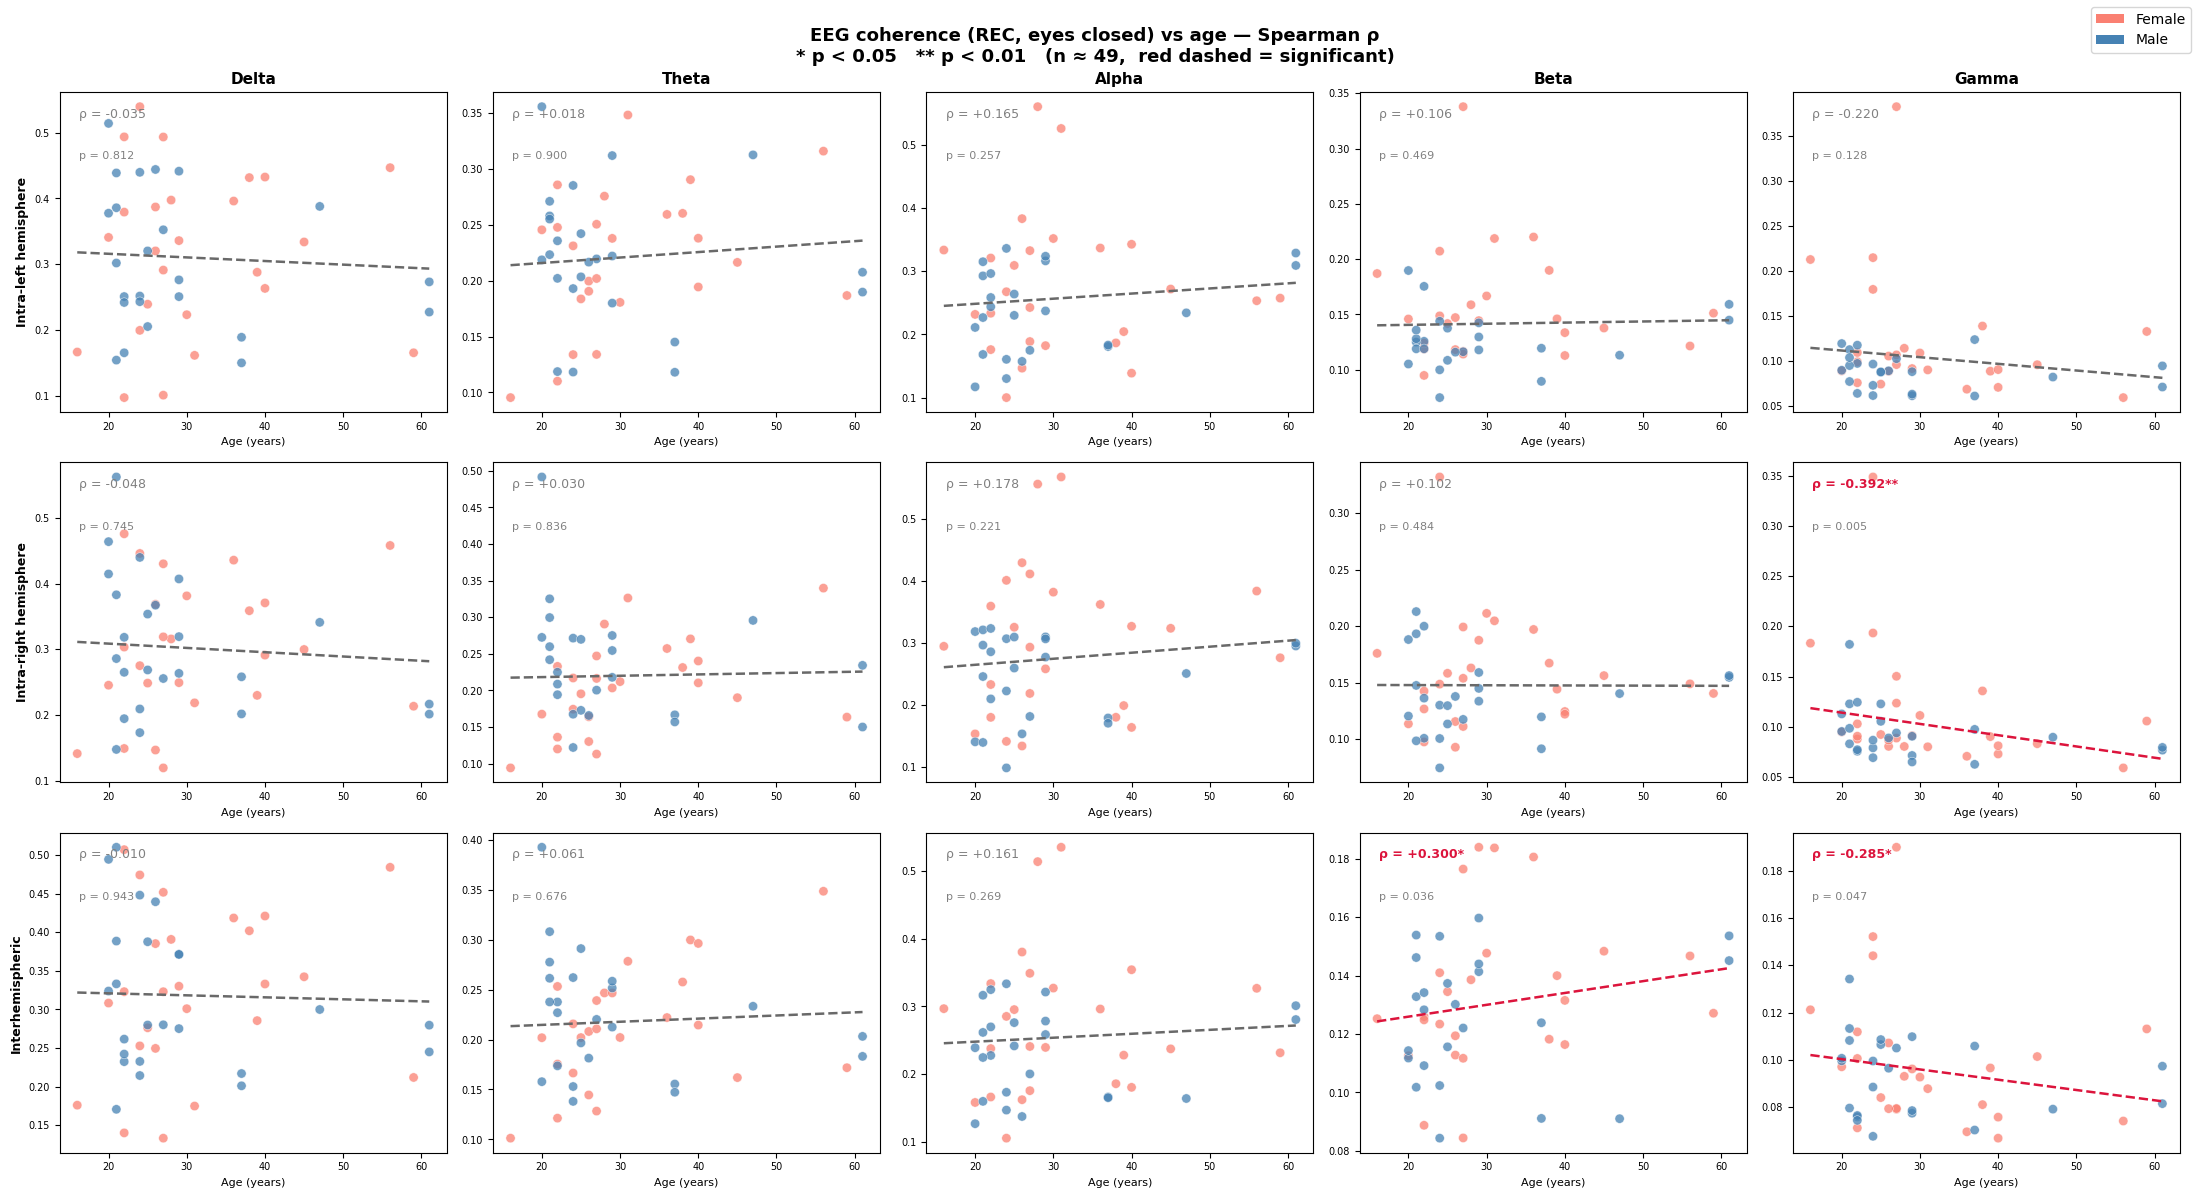

=== Spearman ρ (coherence vs age) — ranked by |ρ| ===

  Feature                                   ρ        p  sig
  -------------------------------------------------------
  intra_right_gamma                    -0.392    0.005  **  ← significant
  interhemispheric_beta                +0.300    0.036  *  ← significant
  interhemispheric_gamma               -0.285    0.047  *  ← significant
  intra_left_gamma                     -0.220    0.128  
  intra_right_alpha                    +0.178    0.221  
  intra_left_alpha                     +0.165    0.257  
  interhemispheric_alpha               +0.161    0.269  
  intra_left_beta                      +0.106    0.469  
  intra_right_beta                     +0.102    0.484  
  interhemispheric_theta               +0.061    0.676  
  intra_right_delta                    -0.048    0.745  
  intra_left_delta                     -0.035    0.812  
  intra_right_theta                    +0.030    0.836  
  intra_left_theta                   

In [11]:
# ============================================================
# CELL COH-3: Coherence vs age — scatter plots + Spearman ρ
#
# 3 rows (intra_left / intra_right / interhemispheric)
# 5 cols (one per frequency band)
# Each panel: scatter coloured by sex + regression line + ρ
#
# We use Spearman rank correlation instead of Pearson because:
#   - age distribution is right-skewed (most subjects 20–35)
#   - effects may be non-linear
#   - robust to the few outlier ages (16, 56, 59, 61)
# ============================================================

from scipy.stats import spearmanr

METRICS = ['intra_left', 'intra_right', 'interhemispheric']
METRIC_LABELS = {
    'intra_left':       'Intra-left hemisphere',
    'intra_right':      'Intra-right hemisphere',
    'interhemispheric': 'Interhemispheric',
}

ages = coh_df['age'].values

fig, axes = plt.subplots(3, 5, figsize=(22, 12))

for row, metric in enumerate(METRICS):
    for col, band in enumerate(BANDS.keys()):
        ax       = axes[row, col]
        col_name = f'{metric}_{band}'
        vals     = coh_df[col_name].values

        r, p = spearmanr(ages, vals)

        # Scatter coloured by sex
        colors = ['salmon' if s == 'Female' else 'steelblue'
                  for s in coh_df['sex']]
        ax.scatter(ages, vals, c=colors, s=45, alpha=0.75,
                   edgecolors='white', linewidth=0.4)

        # Linear regression line (visual guide only)
        m, b   = np.polyfit(ages, vals, 1)
        x_line = np.linspace(ages.min(), ages.max(), 100)
        lc     = 'crimson' if p < 0.05 else 'dimgray'
        ax.plot(x_line, m * x_line + b, color=lc, lw=1.8, linestyle='--')

        # Annotate ρ and p
        sig       = '**' if p < 0.01 else ('*' if p < 0.05 else '')
        text_col  = 'crimson' if p < 0.05 else 'gray'
        fw        = 'bold' if p < 0.05 else 'normal'
        ax.text(0.05, 0.92, f'ρ = {r:+.3f}{sig}',
                transform=ax.transAxes, fontsize=9,
                color=text_col, fontweight=fw)
        ax.text(0.05, 0.79, f'p = {p:.3f}',
                transform=ax.transAxes, fontsize=8, color='gray')

        ax.set_xlabel('Age (years)', fontsize=8)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel(METRIC_LABELS[metric], fontsize=9, fontweight='bold')
        if row == 0:
            ax.set_title(band.capitalize(), fontsize=11, fontweight='bold')

# Legend
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor='salmon',    label='Female'),
                    Patch(facecolor='steelblue', label='Male')],
           loc='upper right', fontsize=10, framealpha=0.8)

plt.suptitle(
    'EEG coherence (REC, eyes closed) vs age — Spearman ρ\n'
    '* p < 0.05   ** p < 0.01   (n ≈ 49,  red dashed = significant)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table ranked by |ρ| ───────────────────────────────────
print("=== Spearman ρ (coherence vs age) — ranked by |ρ| ===")
print(f"\n  {'Feature':<35s}  {'ρ':>6s}  {'p':>7s}  sig")
print("  " + "-" * 55)

rows = []
for metric in METRICS:
    for band in BANDS.keys():
        col_name = f'{metric}_{band}'
        r, p     = spearmanr(ages, coh_df[col_name].values)
        sig      = '**' if p < 0.01 else ('*' if p < 0.05 else '')
        rows.append((col_name, r, p, sig))

rows.sort(key=lambda x: abs(x[1]), reverse=True)
for name, r, p, sig in rows:
    marker = '  ← significant' if sig else ''
    print(f"  {name:<35s}  {r:+.3f}  {p:>7.3f}  {sig}{marker}")

### COH-3 Results: Three significant age–coherence correlations

| Feature | ρ | p | Direction |
|---------|-----|-------|-----------|
| Intra-right γ coherence | −0.392 | 0.005 ** | Decreases with age |
| Interhemispheric β coherence | +0.300 | 0.036 * | Increases with age |
| Interhemispheric γ coherence | −0.285 | 0.047 * | Decreases with age |

**Interpretation:**

- **Gamma coherence (30–50 Hz) decreases with age** — both within the right hemisphere and between hemispheres. Gamma reflects high-frequency processing (attention, memory binding). Its decline with age is well-documented and consistent with reduced neural processing efficiency in ageing.

- **Interhemispheric beta increases with age** — this is consistent with the **HAROLD model** (Cabeza, 2002): older brains tend to recruit both hemispheres more symmetrically as a compensatory mechanism, increasing cross-hemisphere synchronisation.

- **Slow rhythms (delta, theta, alpha) show no significant age effects** — the age-related changes are concentrated in the fast frequencies, which is consistent with the literature on cognitive ageing.

**Important caveat:** the sample contains only ~6 subjects above 50 years. These extreme ages may be driving the correlations. Next cell tests this explicitly.

### COH-4: Robustness check — are the results driven by age extremes?

#### The problem

The sample is young-skewed: most subjects are 20–35 years old, with only ~4 subjects above 50. Significant correlations could be driven entirely by these few older individuals rather than reflecting a genuine age-related trend across the full range.

#### The test

We re-run Spearman correlations on the **three significant findings from COH-3**, excluding subjects older than 50 (n drops from 49 to 45). Three possible outcomes:

- **✓ holds**: correlation remains significant (p < 0.05) → effect is genuine across the full young-to-middle age range
- **~ weakened**: correlation drops below significance but direction preserved → effect partially driven by older extremes
- **✗ disappears**: correlation vanishes → effect was an artefact of the extreme ages

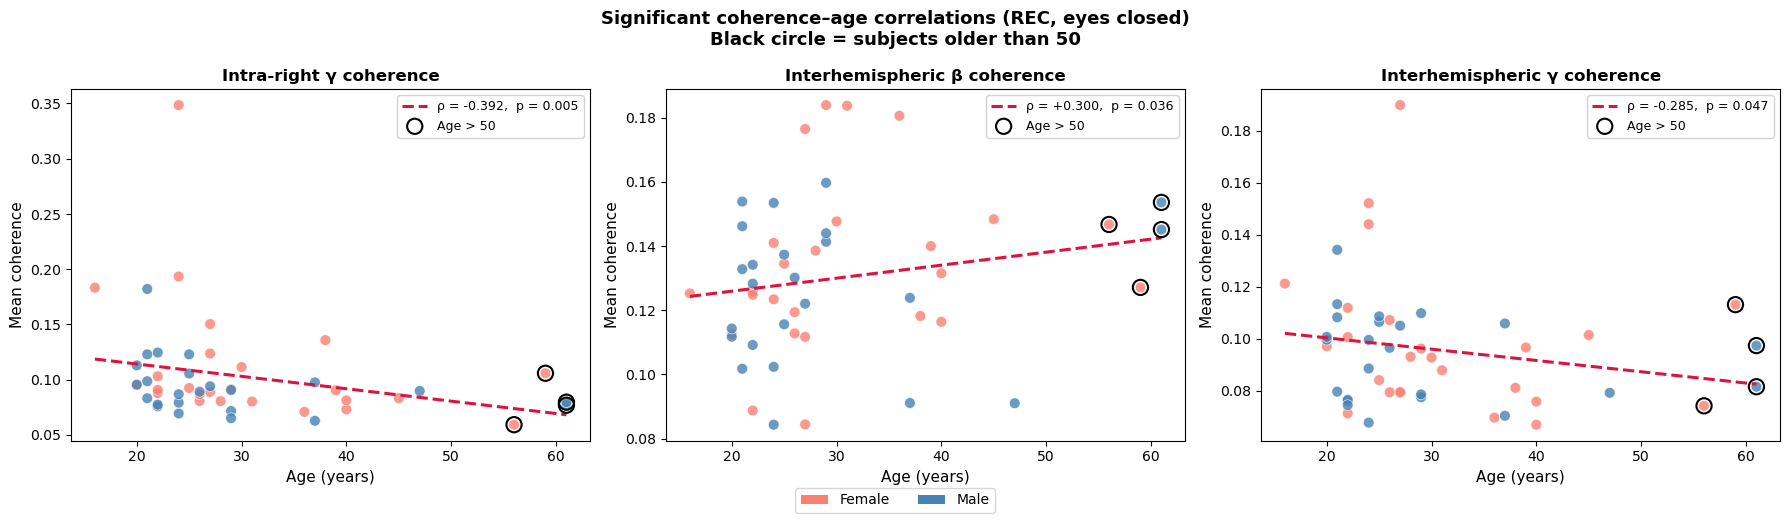

=== Robustness check: full sample vs subjects ≤ 50 ===

  Full sample : n = 49
  Age ≤ 50    : n = 45  (removed 4 subjects)

  Feature                           ρ full    p full     ρ ≤50     p ≤50  verdict
  ----------------------------------------------------------------------------------
  intra_right_gamma                 -0.392     0.005    -0.355     0.017  ✓ holds
  interhemispheric_beta             +0.300     0.036    +0.221     0.145  ~ weakened
  interhemispheric_gamma            -0.285     0.047    -0.327     0.029  ✓ holds


In [12]:
# ============================================================
# CELL COH-4: Focused figure on significant coherence findings
#             + robustness check (remove subjects > 50)
#
# Three significant correlations from COH-3:
#   intra_right_gamma      ρ = -0.392  p = 0.005  **
#   interhemispheric_beta  ρ = +0.300  p = 0.036  *
#   interhemispheric_gamma ρ = -0.285  p = 0.047  *
#
# Robustness check: re-run Spearman on subjects <= 50 years.
# If correlations survive without the 6 older subjects, the
# effect is genuine in the young-to-middle range.
# If they disappear, the effect is driven by age extremes only
# — still reportable, but with a clear caveat.
# ============================================================

from scipy.stats import spearmanr

SIGNIFICANT = [
    ('intra_right_gamma',      'Intra-right γ coherence',     -0.392, 0.005),
    ('interhemispheric_beta',  'Interhemispheric β coherence', +0.300, 0.036),
    ('interhemispheric_gamma', 'Interhemispheric γ coherence', -0.285, 0.047),
]

ages = coh_df['age'].values
sex  = coh_df['sex'].values
colors_sex = ['salmon' if s == 'Female' else 'steelblue' for s in sex]

# ── Panel figure ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label, rho, pval) in zip(axes, SIGNIFICANT):
    vals = coh_df[col].values

    ax.scatter(ages, vals, c=colors_sex, s=60, alpha=0.80,
               edgecolors='white', linewidth=0.5, zorder=3)

    # Regression line
    m, b   = np.polyfit(ages, vals, 1)
    x_line = np.linspace(ages.min(), ages.max(), 200)
    ax.plot(x_line, m * x_line + b,
            color='crimson', lw=2.2, linestyle='--', zorder=4,
            label=f'ρ = {rho:+.3f},  p = {pval:.3f}')

    # Mark the 6 subjects > 50 to make them visible
    old_mask = ages > 50
    ax.scatter(ages[old_mask], vals[old_mask],
               edgecolors='black', facecolors='none',
               s=120, lw=1.5, zorder=5, label='Age > 50')

    ax.set_xlabel('Age (years)', fontsize=11)
    ax.set_ylabel('Mean coherence', fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.85)

from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(facecolor='salmon',    label='Female'),
             Patch(facecolor='steelblue', label='Male')],
    loc='lower center', ncol=2, fontsize=10,
    bbox_to_anchor=(0.5, -0.04), framealpha=0.8)

plt.suptitle(
    'Significant coherence–age correlations (REC, eyes closed)\n'
    'Black circle = subjects older than 50',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Robustness check ──────────────────────────────────────────────
print("=== Robustness check: full sample vs subjects ≤ 50 ===\n")
print(f"  Full sample : n = {len(coh_df)}")
young_df = coh_df[coh_df['age'] <= 50]
print(f"  Age ≤ 50    : n = {len(young_df)}  "
      f"(removed {len(coh_df) - len(young_df)} subjects)\n")

print(f"  {'Feature':<30s}  {'ρ full':>8s}  {'p full':>8s}  "
      f"{'ρ ≤50':>8s}  {'p ≤50':>8s}  verdict")
print("  " + "-" * 82)

for col, label, rho_full, p_full in SIGNIFICANT:
    r2, p2 = spearmanr(young_df['age'].values,
                       young_df[col].values)

    if p2 < 0.05:
        verdict = '✓ holds'
    elif p2 < 0.15:
        verdict = '~ weakened'
    else:
        verdict = '✗ disappears'

    print(f"  {col:<30s}  {rho_full:>+8.3f}  {p_full:>8.3f}  "
          f"{r2:>+8.3f}  {p2:>8.3f}  {verdict}")

### COH-4 Results: Two robust effects, one partially driven by extremes

| Feature | Full sample (n=49) | Age ≤ 50 (n=45) | Verdict |
|---------|-------------------|-----------------|---------|
| Intra-right γ | ρ = −0.392, p = 0.005 | ρ = −0.355, p = 0.017 | **✓ Robust** |
| Interhemispheric γ | ρ = −0.285, p = 0.047 | ρ = −0.327, p = 0.029 | **✓ Robust** |
| Interhemispheric β | ρ = +0.300, p = 0.036 | ρ = +0.221, p = 0.145 | **~ Weakened** |

**Key conclusions:**

1. **Gamma coherence decline with age is robust** — it holds even when restricting to the 16–50 age range (no extreme elderly subjects needed). This is the strongest finding of the coherence analysis.

2. **Beta interhemispheric increase is partially driven by the oldest subjects** — the HAROLD-like compensatory effect is suggestive but should be interpreted with caution given the small number of subjects above 50.

### COH-5: Where in the brain does gamma coherence decline?

#### From summary metrics to spatial maps

COH-3 and COH-4 showed that gamma coherence decreases with age, but used summary metrics (mean across hemisphere pairs). This tells us *how much* coherence changes, not *where*.

Here we return to the **full 14×14 coherence matrices** and average them by age group:
- Young (<30): n = 34
- Middle (30–45): n = 10
- Older (>45): n = 5

The **difference matrix (Older − Young)** reveals which specific electrode pairs lose synchrony with age:
- Blue = lower coherence in older subjects (connections that weaken)
- Red = higher coherence in older subjects (possible compensatory connections)

**Note:** the Older group is small (n = 5). These spatial patterns are exploratory and should be interpreted as hypothesis-generating, not confirmatory.

=== Age group distribution ===
  Young (<30)        : n = 34
  Middle (30–45)     : n = 10
  Older (>45)        : n = 5

Building full coherence matrices per subject...
  Done — 49 subjects
  Young (<30): averaged 34 matrices
  Middle (30–45): averaged 10 matrices
  Older (>45): averaged 5 matrices


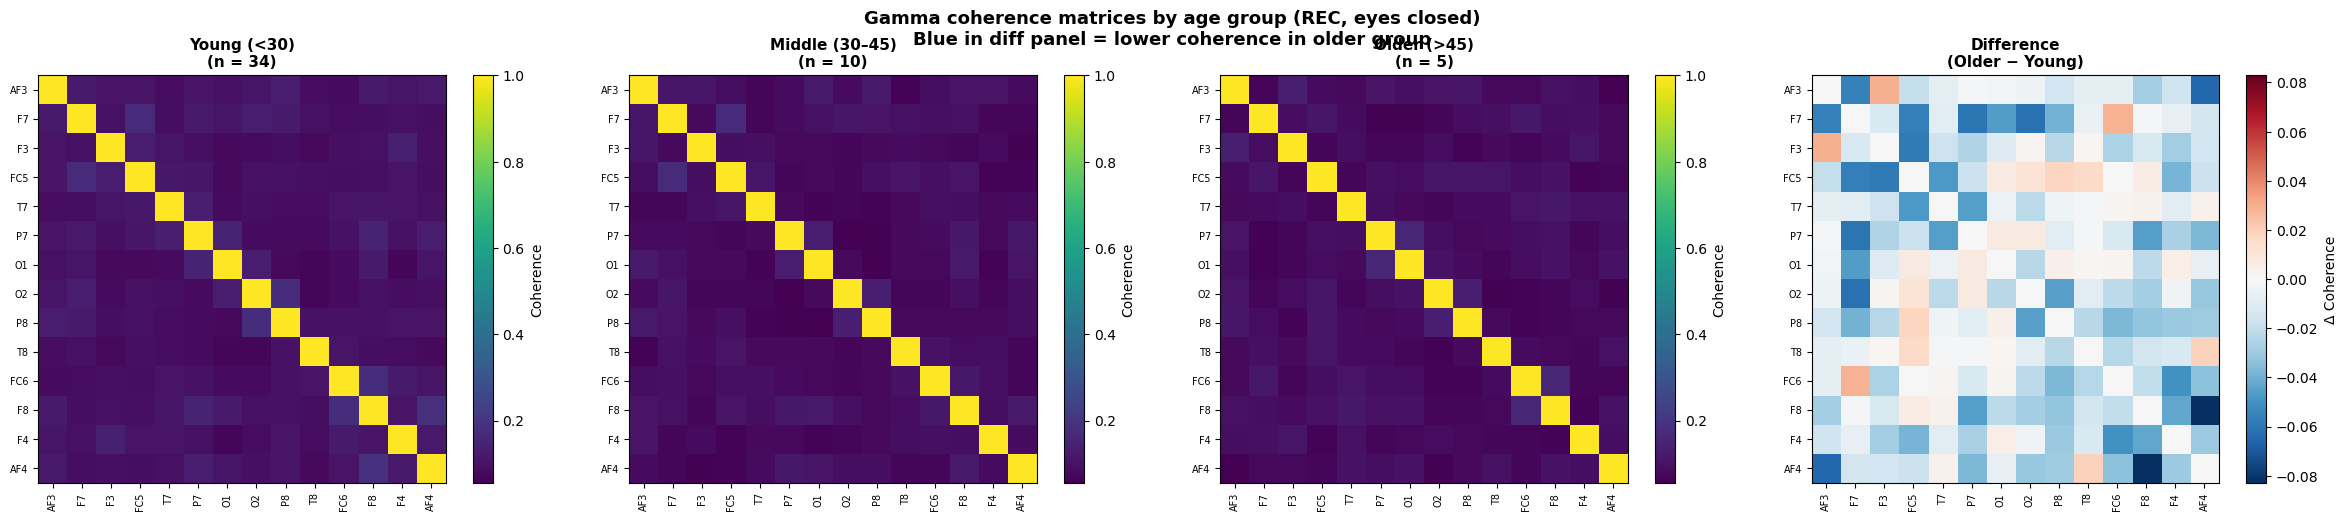


=== Top 10 pairs with largest gamma coherence decrease (Older vs Young) ===
  Left ch — Right ch   Δ coherence
  -----------------------------------
  F8     — AF4      -0.0829
  AF3    — AF4      -0.0651
  F7     — O2       -0.0618
  F7     — P7       -0.0604
  F3     — FC5      -0.0584
  F7     — FC5      -0.0569
  AF3    — F7       -0.0559
  FC6    — F4       -0.0504
  FC5    — T7       -0.0476
  F7     — O1       -0.0463


In [13]:
# ============================================================
# CELL COH-5: Age group coherence heatmaps — gamma band
#
# We compare mean gamma coherence matrices across three age
# groups, then compute the difference (Older - Young) to
# highlight which electrode pairs lose synchrony with age.
#
# Age groups:
#   Young  : age < 30   (majority of the sample)
#   Middle : 30 ≤ age ≤ 45
#   Older  : age > 45
#
# Note: Older group is small (n ≈ 6). Treat as exploratory.
# ============================================================

# ── Define age groups ─────────────────────────────────────────────
def age_group(age):
    if age < 30:   return 'Young (<30)'
    if age <= 45:  return 'Middle (30–45)'
    return 'Older (>45)'

coh_df['age_group'] = coh_df['age'].apply(age_group)
group_order = ['Young (<30)', 'Middle (30–45)', 'Older (>45)']

print("=== Age group distribution ===")
for g in group_order:
    n = (coh_df['age_group'] == g).sum()
    print(f"  {g:<18s} : n = {n}")

# ── Re-compute full 14×14 coherence matrices per subject ──────────
# (COH-2 only kept summary metrics; now we need the full matrix)
print("\nBuilding full coherence matrices per subject...")

subject_coh = {}   # {subject_id: {'gamma': np.ndarray(14,14), ...}}

for _, row in coh_df.iterrows():
    sid      = row['subject_id']
    edf_path = find_edf(sid, session='G10')
    try:
        segs = extract_condition_segments(edf_path)
        rec  = segs.get('REC')
        if rec is not None:
            subject_coh[sid] = compute_coherence_matrix(rec)
    except Exception as e:
        print(f"  {sid}: ERROR {e}")

print(f"  Done — {len(subject_coh)} subjects")

# ── Average matrices per age group ───────────────────────────────
group_matrices = {}
for g in group_order:
    sids = coh_df[coh_df['age_group'] == g]['subject_id'].values
    mats = [subject_coh[s]['gamma'] for s in sids if s in subject_coh]
    group_matrices[g] = np.mean(mats, axis=0)
    print(f"  {g}: averaged {len(mats)} matrices")

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Common color scale across all group panels
vmin = min(M.min() for M in group_matrices.values())
vmax = max(M.max() for M in group_matrices.values())

for ax, g in zip(axes[:3], group_order):
    n   = (coh_df['age_group'] == g).sum()
    M   = group_matrices[g]
    im  = ax.imshow(M, vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_xticks(range(14)); ax.set_xticklabels(EEG_CHANNELS,
                                                  rotation=90, fontsize=7)
    ax.set_yticks(range(14)); ax.set_yticklabels(EEG_CHANNELS, fontsize=7)
    ax.set_title(f'{g}\n(n = {n})', fontweight='bold', fontsize=11)
    plt.colorbar(im, ax=ax, label='Coherence')

# Difference panel: Older − Young
diff = group_matrices['Older (>45)'] - group_matrices['Young (<30)']
vlim = np.abs(diff).max()
ax   = axes[3]
im   = ax.imshow(diff, vmin=-vlim, vmax=vlim, cmap='RdBu_r')
ax.set_xticks(range(14)); ax.set_xticklabels(EEG_CHANNELS,
                                               rotation=90, fontsize=7)
ax.set_yticks(range(14)); ax.set_yticklabels(EEG_CHANNELS, fontsize=7)
ax.set_title('Difference\n(Older − Young)', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax, label='Δ Coherence')

plt.suptitle('Gamma coherence matrices by age group (REC, eyes closed)\n'
             'Blue in diff panel = lower coherence in older group',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print the 10 pairs with largest decrease in Older ────────────
iu = np.triu_indices(14, k=1)
pair_diffs = [(EEG_CHANNELS[i], EEG_CHANNELS[j], diff[i, j])
              for i, j in zip(iu[0], iu[1])]
pair_diffs.sort(key=lambda x: x[2])   # most negative = biggest decrease

print("\n=== Top 10 pairs with largest gamma coherence decrease (Older vs Young) ===")
print(f"  {'Left ch':6s} — {'Right ch':6s}   Δ coherence")
print("  " + "-" * 35)
for ch1, ch2, d in pair_diffs[:10]:
    print(f"  {ch1:6s} — {ch2:6s}   {d:+.4f}")

### COH-5 Results: Bilateral frontal gamma disconnection with age

The difference heatmap reveals a clear spatial pattern in gamma coherence decline:

**Right frontal pairs show the strongest decrease:**
- F8–AF4 (Δ = −0.083) and FC6–F4 (Δ = −0.050) — consistent with the intra-right gamma correlation from COH-3

**Left frontal channel F7 is involved in 5 of the top 10 declining pairs:**
- F7–O2, F7–P7, F7–FC5, AF3–F7, F7–O1 — indicating that the left frontal cortex also loses long-range gamma connections with age

**Interpretation:** The pattern is **bilateral frontal gamma disconnection**, with the right hemisphere more affected. This is consistent with the well-documented vulnerability of prefrontal cortex to age-related changes in high-frequency neural coordination. The right-hemisphere predominance aligns with the lateralised decline of visuospatial processing networks, which rely heavily on right prefrontal gamma synchronisation.

The few red spots (increased coherence in older subjects) appear in temporal-parietal left pairs, possibly reflecting compensatory reorganisation, but with n = 5 in the Older group this remains speculative.

### COH-6: Does coherence improve age classification?

#### Rationale

COH-3 found significant correlations between gamma coherence and age. But correlation ≠ classification: a variable can correlate with age at the group level without being useful for predicting the age group of an individual subject.

Here we test whether adding the 15 coherence features to the existing 70 PSD features improves binary age classification (Young <30 vs Older ≥30).

#### Method
- **Classifiers**: Random Forest (200 trees) + SVM (RBF kernel), both with StandardScaler
- **Evaluation**: 5-fold stratified cross-validation, balanced accuracy
- **Baseline**: PSD relative band power only (70 features, from Part 1)
- **Chance level**: 50% (binary classification)

In [15]:
# ============================================================
# CELL COH-6 (fixed): Save coherence features + age classification
#
# Self-contained version — does not depend on cond_matrices_rel.
# Recomputes PSD features for REC on the fly using only objects
# already in memory: coh_df, find_edf, extract_condition_segments.
# ============================================================

from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.pipeline        import Pipeline
from scipy.signal            import welch
import warnings
warnings.filterwarnings('ignore')

# ── Local definitions (safe to redefine) ─────────────────────────
BANDS_LOCAL = {
    'delta': (1,  4),
    'theta': (4,  8),
    'alpha': (8, 13),
    'beta' : (13, 30),
    'gamma': (30, 50),
}

def compute_psd_features_rec(segment, sfreq=SFREQ, bands=BANDS_LOCAL):
    """Mean band power per channel (Welch) for one segment."""
    features, names = [], []
    for ch_idx, ch_name in enumerate(EEG_CHANNELS):
        f, psd = welch(segment[ch_idx, :], fs=sfreq,
                       nperseg=min(256, segment.shape[1]))
        for band, (flo, fhi) in bands.items():
            mask = (f >= flo) & (f < fhi)
            features.append(psd[mask].mean() * 1e12)
            names.append(f'{ch_name}_{band}')
    return np.array(features), names

# ── 1. Recompute PSD for REC for all subjects in coh_df ──────────
print("Computing PSD features for REC condition...")
psd_records  = []
psd_feat_names = None

for _, row in coh_df.iterrows():
    sid      = row['subject_id']
    edf_path = find_edf(sid, session='G10')
    try:
        segs = extract_condition_segments(edf_path)
        rec  = segs.get('REC')
        if rec is None:
            continue
        feats, names = compute_psd_features_rec(rec)
        if psd_feat_names is None:
            psd_feat_names = names
        rec_row = {'subject_id': sid}
        rec_row.update(dict(zip(names, feats)))
        psd_records.append(rec_row)
    except Exception as e:
        print(f"  {sid}: ERROR {e}")

psd_rec_df = pd.DataFrame(psd_records)

# Relative band power normalisation (same as Part 2)
X_raw = psd_rec_df[psd_feat_names].values
row_sum = X_raw.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1
psd_rec_df[psd_feat_names] = X_raw / row_sum

print(f"  PSD computed for {len(psd_rec_df)} subjects\n")

# ── 2. Merge PSD + coherence on subject_id ───────────────────────
coh_feat_cols = [c for c in coh_df.columns
                 if c.startswith(('intra_', 'interhemispheric_'))]

merged = psd_rec_df.merge(
    coh_df[['subject_id'] + coh_feat_cols + ['age', 'sex', 'handedness']],
    on='subject_id'
)

print(f"✓ Merged: {len(merged)} subjects — "
      f"PSD ({len(psd_feat_names)}) + coherence ({len(coh_feat_cols)}) features\n")

# ── 3. Save coherence features ────────────────────────────────────
SAVE_PATH = PROJECT_ROOT / 'coherence_features_REC.csv'
coh_df.to_csv(SAVE_PATH, index=False)
print(f"✓ Coherence features saved → {SAVE_PATH}\n")

# ── 4. Labels ─────────────────────────────────────────────────────
X_psd  = merged[psd_feat_names].values
X_coh  = merged[coh_feat_cols].values
X_both = np.hstack([X_psd, X_coh])

y_age2 = LabelEncoder().fit_transform(
             pd.cut(merged['age'], bins=[0, 30, 100],
                    labels=['Young', 'Older']))

print("=== Age binary split (Young <30  vs  Older >=30) ===")
for label, count in zip(*np.unique(y_age2, return_counts=True)):
    print(f"  Class {label}: {count} subjects")

# ── 5. Classification ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_rf  = Pipeline([('sc', StandardScaler()),
                    ('cl', RandomForestClassifier(
                        n_estimators=200, random_state=42))])
clf_svm = Pipeline([('sc', StandardScaler()),
                    ('cl', SVC(kernel='rbf', C=1.0,
                               gamma='scale', random_state=42))])

feature_sets = {
    'PSD only (70)'        : X_psd,
    'Coherence only (15)'  : X_coh,
    'PSD + Coherence (85)' : X_both,
}

print("\n=== Age classification — balanced accuracy ===")
print(f"  Chance level: 50%\n")
print(f"  {'Features':<26s}  {'RF':>8s}  {'SVM':>8s}")
print("  " + "-" * 46)

results_coh = {}
for label, X_t in feature_sets.items():
    sc_rf  = cross_val_score(clf_rf,  X_t, y_age2,
                             cv=cv,
                             scoring='balanced_accuracy').mean()
    sc_svm = cross_val_score(clf_svm, X_t, y_age2,
                             cv=cv,
                             scoring='balanced_accuracy').mean()
    results_coh[label] = (sc_rf, sc_svm)
    print(f"  {label:<26s}  {sc_rf:>8.3f}  {sc_svm:>8.3f}")

# ── 6. Summary ────────────────────────────────────────────────────
best_psd  = max(results_coh['PSD only (70)'])
best_coh  = max(results_coh['Coherence only (15)'])
best_both = max(results_coh['PSD + Coherence (85)'])
delta     = best_both - best_psd

print(f"\n=== Interpretation ===")
print(f"  PSD only best       : {best_psd:.3f}")
print(f"  Coherence only best : {best_coh:.3f}")
print(f"  Combined best       : {best_both:.3f}")
print(f"  Δ (combined − PSD)  : {delta:+.3f}")

if delta > 0.02:
    print("  → Coherence adds meaningful information beyond PSD.")
elif delta > 0:
    print("  → Marginal gain: coherence adds little beyond PSD.")
else:
    print("  → No gain: coherence does not improve age classification.")
print("    Note: with n=49 this result is underpowered regardless of direction.")

Computing PSD features for REC condition...
  PSD computed for 49 subjects

✓ Merged: 49 subjects — PSD (70) + coherence (15) features

✓ Coherence features saved → C:\Users\Laura\OneDrive\Escritorio\TFM_part1\coherence_features_REC.csv

=== Age binary split (Young <30  vs  Older >=30) ===
  Class 0: 14 subjects
  Class 1: 35 subjects

=== Age classification — balanced accuracy ===
  Chance level: 50%

  Features                          RF       SVM
  ----------------------------------------------
  PSD only (70)                  0.569     0.500
  Coherence only (15)            0.452     0.500
  PSD + Coherence (85)           0.569     0.500

=== Interpretation ===
  PSD only best       : 0.569
  Coherence only best : 0.500
  Combined best       : 0.569
  Δ (combined − PSD)  : +0.000
  → No gain: coherence does not improve age classification.
    Note: with n=49 this result is underpowered regardless of direction.


### COH-6 Results: Coherence does not improve age classification

| Features | RF | SVM |
|----------|-------|-------|
| PSD only (70) | 0.569 | 0.500 |
| Coherence only (15) | 0.452 | 0.500 |
| PSD + Coherence (85) | 0.569 | 0.500 |

**Combined features (Δ = 0.000)** — coherence adds no classification power.

**This does not contradict the significant correlations from COH-3.** The distinction is important:

- **Correlation** asks: *is there a group-level trend?* → Yes (ρ = −0.39, p = 0.005). The gamma coherence decline with age is real.
- **Classification** asks: *can I predict an individual's age group?* → No. The correlation explains ~15% of variance; the remaining 85% is individual variability unrelated to age.

Additionally, the class imbalance (35 Young vs 14 Older) means each CV fold has only 2-3 Older subjects in the test set — insufficient for reliable classification.

**Conclusion:** coherence provides valuable *interpretive* information about age-related brain changes, but does not add *predictive* power beyond PSD in this sample.

## AGE-REG: Can we predict age continuously instead of classifying it?

### Why regression instead of classification?

Age classification (COH-6) failed partly because of the artificial group split: a 29-year-old is "Young" and a 31-year-old is "Older", despite being only 2 years apart. **Regression** avoids this by predicting age as a continuous number, measuring error in years (MAE).

### Feature selection: targeted age-sensitive features

Instead of using all 70 PSD or 15 coherence features (most of which showed no age effect), we select only **6 features** with known or demonstrated age sensitivity:

| Feature | Source | Why age-sensitive |
|---------|--------|-------------------|
| IAF at O1, O2 | Literature | Alpha peak frequency decreases with age (~10 Hz → ~8 Hz) |
| Theta/alpha frontal ratio | Literature | Theta rises and alpha falls with age → ratio increases |
| Gamma coherence (3 metrics) | COH-3/COH-4 | Significant robust correlations with age in our data |


### References: age-sensitive EEG features

**IAF (Individual Alpha Frequency) decreases with age:**

- Klimesch, W. (1999). EEG alpha and theta oscillations reflect cognitive and memory performance: a review and analysis. *Brain Research Reviews*, 29(2–3), 169–195.
- Grandy, T. H., Werkle-Bergner, M., Chicherio, C., Schmiedek, F., Lövdén, M., & Lindenberger, U. (2013). Peak individual alpha frequency qualifies as a stable neurophysiological trait marker in healthy younger and older adults. *Psychophysiology*, 50(6), 570–582.

**Theta/alpha ratio increases with age:**

- Moretti, D. V., Babiloni, C., Binetti, G., Cassetta, E., Dal Forno, G., Ferreric, F., ... & Rossini, P. M. (2004). Individual analysis of EEG frequency and band power in mild Alzheimer's disease. *Clinical Neurophysiology*, 115(2), 299–308.
- Finnigan, S., & Robertson, I. H. (2011). Resting EEG theta power correlates with cognitive performance in healthy older adults. *Psychophysiology*, 48(8), 1083–1087.

**Gamma coherence decreases with age:**

- Böttger, D., Herrmann, C. S., & von Cramon, D. Y. (2002). Amplitude differences of evoked alpha and gamma oscillations in two different age groups. *International Journal of Psychophysiology*, 45(3), 245–251.
- Vysata, O., Kukal, J., Prochazka, A., Pazdera, L., Simko, J., & Valis, M. (2014). Age-related changes in EEG coherence. *Neurologia i Neurochirurgia Polska*, 48(1), 35–38.

### Models and baseline

- **Dummy (mean age)**: always predicts the sample mean (~30 years) — the baseline to beat
- **Ridge regression**: linear model with regularisation
- **Random Forest**: non-linear model

Evaluated with 5-fold cross-validation using `cross_val_predict` (each subject predicted only when held out).

In [16]:
# ============================================================
# CELL AGE-REG: Age regression with targeted features
#
# Instead of classifying age into groups (which failed due to
# class imbalance), we predict age as a continuous value.
#
# Targeted age-sensitive features (from the literature):
#   - IAF (Individual Alpha Frequency) at O1, O2 — alpha slows
#     with age; strongest single EEG age marker
#   - theta/alpha ratio at frontal channels — rises with age
#   - gamma coherence (intra_right, interhemispheric) — from COH
#
# Models: Ridge + RandomForest, vs a Dummy baseline (mean age).
# Metric: MAE (years) + correlation between true and predicted age.
# All evaluated with 5-fold CV (cross_val_predict for honest preds).
# ============================================================

from scipy.signal            import welch
from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor
from sklearn.dummy           import DummyRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics         import mean_absolute_error
from scipy.stats             import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

BANDS_LOCAL = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13),
               'beta': (13, 30), 'gamma': (30, 50)}
FRONTAL = ['AF3', 'F7', 'F3', 'F4', 'F8', 'AF4']

def extract_age_features(segment, sfreq=SFREQ):
    """IAF (O1,O2) + frontal theta/alpha ratio for one REC segment."""
    feats = {}

    # --- IAF: peak frequency in 7-14 Hz at O1 and O2 ---
    for ch in ['O1', 'O2']:
        idx = EEG_CHANNELS.index(ch)
        f, psd = welch(segment[idx], fs=sfreq, nperseg=min(256, segment.shape[1]))
        amask = (f >= 7) & (f <= 14)
        feats[f'iaf_{ch}'] = f[amask][np.argmax(psd[amask])]

    # --- Frontal theta/alpha ratio (mean across frontal channels) ---
    ratios = []
    for ch in FRONTAL:
        idx = EEG_CHANNELS.index(ch)
        f, psd = welch(segment[idx], fs=sfreq, nperseg=min(256, segment.shape[1]))
        theta = psd[(f >= 4) & (f < 8)].mean()
        alpha = psd[(f >= 8) & (f < 13)].mean()
        ratios.append(theta / (alpha + 1e-12))
    feats['theta_alpha_frontal'] = np.mean(ratios)

    return feats

# ── Build feature table for all coh_df subjects ──────────────────
print("Extracting targeted age features...")
rows = []
for _, row in coh_df.iterrows():
    sid = row['subject_id']
    try:
        segs = extract_condition_segments(find_edf(sid, session='G10'))
        rec  = segs.get('REC')
        if rec is None:
            continue
        rec_feats = extract_age_features(rec)
        rec_feats['subject_id'] = sid
        rows.append(rec_feats)
    except Exception as e:
        print(f"  {sid}: ERROR {e}")

age_feat_df = pd.DataFrame(rows).merge(
    coh_df[['subject_id', 'age',
            'intra_left_gamma', 'intra_right_gamma',
            'interhemispheric_gamma']],
    on='subject_id'
)

FEATURE_COLS = ['iaf_O1', 'iaf_O2', 'theta_alpha_frontal',
                'intra_left_gamma', 'intra_right_gamma',
                'interhemispheric_gamma']

X = age_feat_df[FEATURE_COLS].values
y = age_feat_df['age'].values
print(f"  {len(age_feat_df)} subjects × {len(FEATURE_COLS)} features\n")

# ── Models ────────────────────────────────────────────────────────
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Dummy (mean age)' : DummyRegressor(strategy='mean'),
    'Ridge'            : Pipeline([('sc', StandardScaler()),
                                   ('m', Ridge(alpha=1.0))]),
    'Random Forest'    : RandomForestRegressor(n_estimators=300,
                                               random_state=42),
}

print("=== Age regression — 5-fold CV ===")
print(f"  Age range: {y.min():.0f}-{y.max():.0f}  |  mean: {y.mean():.1f} years\n")
print(f"  {'Model':<20s}  {'MAE (yrs)':>10s}  {'r (pred,true)':>14s}  {'p':>7s}")
print("  " + "-" * 58)

for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=cv)
    mae    = mean_absolute_error(y, y_pred)
    if name == 'Dummy (mean age)':
        print(f"  {name:<20s}  {mae:>10.2f}  {'—':>14s}  {'—':>7s}")
        dummy_mae = mae
    else:
        r, p = pearsonr(y, y_pred)
        flag = '  ↓ better' if mae < dummy_mae else '  ↑ worse'
        print(f"  {name:<20s}  {mae:>10.2f}  {r:>+14.3f}  {p:>7.3f}{flag}")

# ── Interpretation ────────────────────────────────────────────────
best_model = min(
    [(n, mean_absolute_error(y, cross_val_predict(m, X, y, cv=cv)))
     for n, m in models.items() if n != 'Dummy (mean age)'],
    key=lambda t: t[1])

print(f"\n=== Interpretation ===")
print(f"  Dummy baseline MAE : {dummy_mae:.2f} years")
print(f"  Best model MAE     : {best_model[1]:.2f} years ({best_model[0]})")
improvement = dummy_mae - best_model[1]
print(f"  Improvement        : {improvement:+.2f} years")

if improvement > 1.5:
    print("  → Model predicts age better than chance. Real signal present.")
elif improvement > 0:
    print("  → Marginal: slightly better than guessing the mean.")
else:
    print("  → No predictive value: cannot beat predicting the mean age.")

Extracting targeted age features...
  49 subjects × 6 features

=== Age regression — 5-fold CV ===
  Age range: 16-61  |  mean: 30.1 years

  Model                  MAE (yrs)   r (pred,true)        p
  ----------------------------------------------------------
  Dummy (mean age)            8.67               —        —
  Ridge                       9.68          +0.132    0.364  ↑ worse
  Random Forest               8.86          +0.130    0.371  ↑ worse

=== Interpretation ===
  Dummy baseline MAE : 8.67 years
  Best model MAE     : 8.86 years (Random Forest)
  Improvement        : -0.19 years
  → No predictive value: cannot beat predicting the mean age.


### AGE-REG Results: No predictive power at the individual level

| Model | MAE (years) | r (predicted vs true) | p |
|-------|------------|----------------------|-------|
| Dummy (mean age) | 8.67 | — | — |
| Ridge | 9.68 | +0.132 | 0.364 |
| Random Forest | 8.86 | +0.130 | 0.371 |

Neither model outperforms the dummy baseline. The correlation between predicted and true age is not significant (r ≈ 0.13, p ≈ 0.37).

### Why does this fail when individual correlations were significant?

This is not a contradiction — **correlation and prediction answer different questions:**

- A significant correlation (ρ = −0.39) means there is a *detectable trend* at the group level: older subjects tend to have lower gamma coherence
- But that correlation explains only ~15% of the variance (ρ² ≈ 0.15). The remaining 85% is inter-individual variability unrelated to age (anatomy, electrode contact, genetics, cognitive state...)
- For a group-level trend, 15% is enough. For individual prediction, it means two subjects with identical coherence values could be 20 or 55 years old

### Conclusion on age

Age-related EEG effects exist and are detectable (gamma coherence ρ = −0.39, p = 0.005), but they are too weak relative to individual variability to predict age at the single-subject level — whether by classification or regression. This is consistent with the young, narrow-range sample (most subjects 20–35) and the consumer-grade EEG device (14 channels, 128 Hz).